ONLINE SHOPPING ORDERS DATASET

First 5 Rows
   Order_ID  Customer_Age  Gender Product_Category  Quantity  Price  \
0       101            23  Female      Electronics         2  45000   
1       102            30    Male         Clothing         3   2500   
2       103            21  Female          Grocery         8   1200   
3       104            40    Male        Furniture         1  15000   
4       105            28  Female           Beauty         4   3000   

  Payment_Method  Rating  
0            UPI       5  
1           Card       4  
2           Cash       5  
3           Card       3  
4            UPI       4  

Last 5 Rows
   Order_ID  Customer_Age  Gender Product_Category  Quantity  Price  \
5       106            35    Male      Electronics         1  60000   
6       107            24  Female         Clothing         2   1800   
7       108            32    Male          Grocery        10   2200   
8       109            27  Female           Beauty         5   4500  

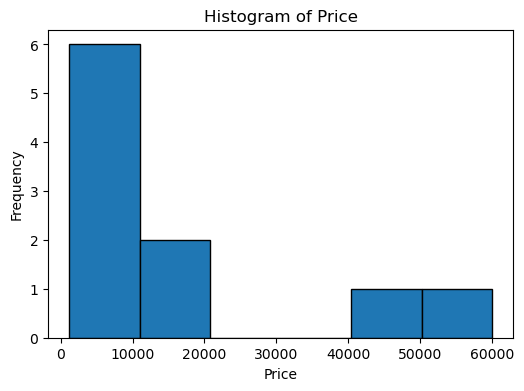

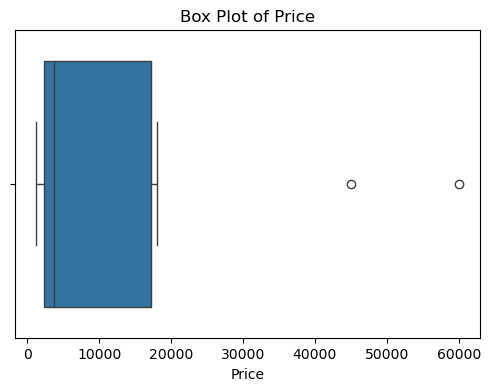

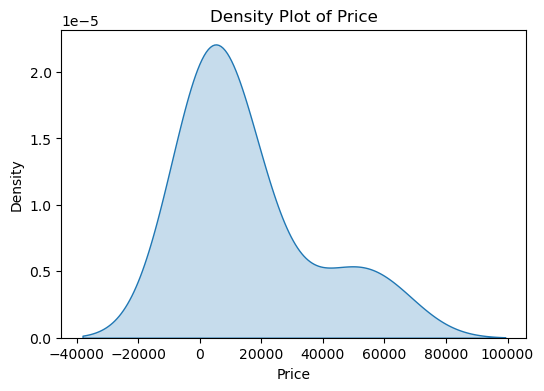

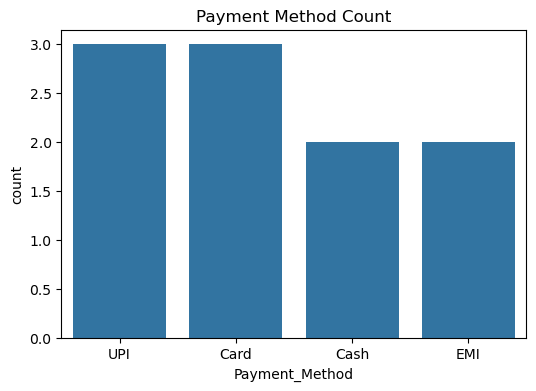

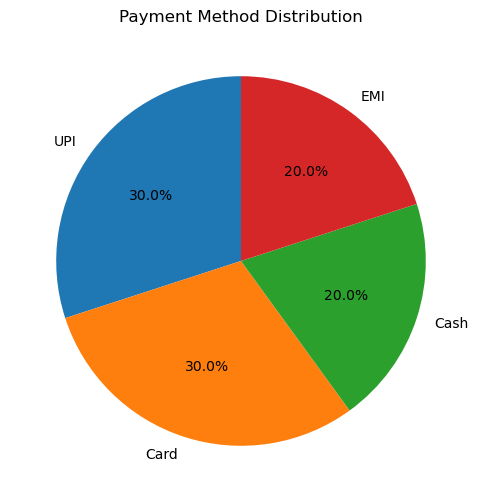


OBSERVATIONS
Average Order Price : 15320.00
Most Common Payment Method : Card
Least Common Payment Method : Cash
Outliers Found : Yes

Project Completed Successfully!


In [1]:
# ================================
# UNIVARIATE EDA PROJECT
# Online Shopping Orders Dataset
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Create Dataset
# -------------------------------
data = {
    "Order_ID":[101,102,103,104,105,106,107,108,109,110],
    "Customer_Age":[23,30,21,40,28,35,24,32,27,29],
    "Gender":["Female","Male","Female","Male","Female","Male","Female","Male","Female","Male"],
    "Product_Category":["Electronics","Clothing","Grocery","Furniture","Beauty",
                        "Electronics","Clothing","Grocery","Beauty","Furniture"],
    "Quantity":[2,3,8,1,4,1,2,10,5,1],
    "Price":[45000,2500,1200,15000,3000,60000,1800,2200,4500,18000],
    "Payment_Method":["UPI","Card","Cash","Card","UPI","EMI","Cash","UPI","Card","EMI"],
    "Rating":[5,4,5,3,4,5,4,5,3,4]
}

df = pd.DataFrame(data)

print("="*60)
print("ONLINE SHOPPING ORDERS DATASET")
print("="*60)

# -------------------------------
# Basic Information
# -------------------------------
print("\nFirst 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nShape:", df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics")
print(df.describe())

# -------------------------------
# Univariate Analysis (Price)
# -------------------------------
print("\n" + "="*60)
print("PRICE ANALYSIS")
print("="*60)

print("Mean:", df["Price"].mean())
print("Median:", df["Price"].median())
print("Mode:", df["Price"].mode()[0])
print("Minimum:", df["Price"].min())
print("Maximum:", df["Price"].max())
print("Range:", df["Price"].max()-df["Price"].min())
print("Variance:", df["Price"].var())
print("Standard Deviation:", df["Price"].std())

print("\nQuartiles")
print(df["Price"].quantile([0.25,0.5,0.75]))

# -------------------------------
# IQR Outlier Detection
# -------------------------------
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df["Price"] < lower) | (df["Price"] > upper)]

print("\nIQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)

print("\nOutliers")
print(outliers)

# -------------------------------
# Payment Method Analysis
# -------------------------------
print("\n" + "="*60)
print("PAYMENT METHOD ANALYSIS")
print("="*60)

print("\nFrequency")
print(df["Payment_Method"].value_counts())

print("\nPercentage")
print(round(df["Payment_Method"].value_counts(normalize=True)*100,2))

# -------------------------------
# Visualizations
# -------------------------------
plt.figure(figsize=(6,4))
plt.hist(df["Price"], bins=6, edgecolor="black")
plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Price"])
plt.title("Box Plot of Price")
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(df["Price"], fill=True)
plt.title("Density Plot of Price")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Payment_Method", data=df)
plt.title("Payment Method Count")
plt.show()

plt.figure(figsize=(6,6))
df["Payment_Method"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

# -------------------------------
# Observations
# -------------------------------
print("\n" + "="*60)
print("OBSERVATIONS")
print("="*60)

print(f"Average Order Price : {df['Price'].mean():.2f}")
print("Most Common Payment Method :", df["Payment_Method"].mode()[0])
print("Least Common Payment Method :", df["Payment_Method"].value_counts().idxmin())

if len(outliers) > 0:
    print("Outliers Found : Yes")
else:
    print("Outliers Found : No")

print("\nProject Completed Successfully!")